# 🧬 Prédiction de l'Âge Biologique à partir de la Méthylation de l'ADN

Ce notebook explore différentes approches de machine learning pour prédire l'âge biologique à partir de données de méthylation de l'ADN (sites CpG).

## 📋 Table des matières
1. [Chargement et préparation des données](#1-chargement-et-préparation)
2. [Modèles de base](#2-modèles-de-base)
3. [Optimisations](#3-optimisations)
4. [Méthodes avancées](#4-méthodes-avancées)
5. [Ensembles de modèles](#5-ensembles)
6. [Résultats finaux](#6-résultats-finaux)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Chargement et Préparation des Données 📊

### Imports des bibliothèques

In [2]:
!pip install xgboost

In [3]:
# Bibliothèques de base
import numpy as np
import pandas as pd

# Statistiques
from scipy.stats import pearsonr
from scipy.optimize import minimize

# Scikit-learn - Préparation des données
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Scikit-learn - Réduction de dimensionnalité
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Scikit-learn - Modèles
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.linear_model import LinearRegression, Ridge, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

# XGBoost
from xgboost import XGBRegressor

# Ignorer les warnings pour plus de clarté
import warnings
warnings.filterwarnings('ignore')

### Chargement du dataset

Le dataset contient :
- **Variable cible** : `age` (l'âge biologique à prédire)
- **Features** : Sites CpG (marqueurs de méthylation de l'ADN)

Les sites CpG sont des régions de l'ADN où la méthylation peut indiquer l'âge biologique.

In [4]:
# Installation RAPIDS compatible Colab
!pip install cudf-cu12 --extra-index-url=https://pypi.nvidia.com


Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.2/684.2 MB 39.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.7/737.7 kB 199.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 159.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 200.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 104.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 121.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 193.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 193.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 171.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 179.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39

In [ ]:
import cudf
print("cuDF version:", cudf.__version__)


cuDF version: 26.02.01


In [5]:
# Chargement des données
import pandas as pd
import os

# path = os.path.join("wide_parquet/wide_parquet", "part_0000.parquet")

# df = pd.read_parquet(path)
import pandas as pd

path = "/content/drive/MyDrive/NdiayeLambert/donnees_net.parquet"
df = pd.read_parquet(path)



In [ ]:
print("Colonnes :", df.columns[:20])
print("Index :", df.index[:20])



Colonnes : Index(['692063', '884377', '788329', '702660', '877341', '415014', '179795',
       '453640', '675228', '450329', '761545', '779851', '269862', '754045',
       '605325', '537214', '632731', '450685', '436747', '98617'],
      dtype='object')
Index : RangeIndex(start=0, stop=20, step=1)


In [6]:
df.shape

(388, 300001)

In [7]:
df

,692063,884377,788329,702660,877341,415014,179795,453640,675228,450329,...,860751,725189,54942,303796,366021,1992,166685,117487,150870,age
0,0.029797,0.973523,0.914712,0.967906,0.011993,0.960497,0.957516,0.051877,0.962399,0.048022,...,0.098383,0.777000,0.879134,0.869860,0.941372,0.834801,0.915566,0.145254,0.867757,31.35
1,0.963468,0.969675,0.960579,0.974676,0.954345,0.957091,0.968399,0.968577,0.035928,0.911770,...,0.135008,0.844822,0.887514,0.891259,0.949414,0.873702,0.930488,0.122613,0.867323,79.45
2,0.955803,0.972206,0.033240,0.044533,0.957142,0.966047,0.081152,0.959076,0.037680,0.030821,...,0.081051,0.744090,0.872002,0.884800,0.926086,0.830155,0.917690,0.121595,0.825237,60.42
3,0.032031,0.025832,0.026395,0.043351,0.155203,0.035457,0.088820,0.942256,0.952689,0.039986,...,0.112415,0.747983,0.915664,0.838103,0.929289,0.853374,0.835813,0.103286,0.896834,59.24
4,0.027245,0.021590,0.942167,0.963882,0.017945,0.963781,0.973429,0.959836,0.038906,0.894327,...,0.128861,0.783899,0.927989,0.888320,0.947971,0.860760,0.922050,0.158046,0.861779,22.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,0.952862,0.962253,0.035054,0.955107,0.224109,0.956685,0.963110,0.954248,0.037218,0.058971,...,0.136177,0.782378,0.903860,0.864510,0.942008,0.846385,0.911774,0.117832,0.875946,26.87
384,0.954972,0.968844,0.028030,0.962526,0.011414,0.021953,0.966514,0.943914,0.044808,0.048011,...,0.102114,0.728425,0.900675,0.880726,0.920630,0.812737,0.878786,0.117510,0.842837,72.65
385,0.030676,0.020334,0.030320,0.961601,0.012075,0.957413,0.971675,0.039759,0.037373,0.044175,...,0.097966,0.749506,0.928614,0.868637,0.922282,0.874474,0.895890,0.153980,0.883413,45.05
386,0.966913,0.020648,0.948330,0.942776,0.018781,0.946968,0.965518,0.954222,0.031185,0.862921,...,0.105930,0.806702,0.920630,0.892066,0.931791,0.823112,0.929195,0.112343,0.896480,77.06


In [10]:
y_series = df['age']
X = df.drop(columns=['age'])
# Ensure y is aligned with X after all filtering steps
#y = y_series.loc[X.index].values

X = X.loc[y_series.index]

print("Samples:", X.shape[0])
print("Features (CpG):", X.shape[1])
print("Age mean:", y_series.mean())

Samples: 388
Features (CpG): 300000
Age mean: 52.97463917525773


### Nettoyage des données

**Étapes :**
1. **Imputation des valeurs manquantes** : remplacement par la médiane (plus robuste que la moyenne)
2. **Suppression des features constantes** : colonnes avec variance = 0 n'apportent aucune information

In [9]:
y=df["age"]
X=df.drop("age",axis=1)
X

,692063,884377,788329,702660,877341,415014,179795,453640,675228,450329,...,4975,860751,725189,54942,303796,366021,1992,166685,117487,150870
0,0.029797,0.973523,0.914712,0.967906,0.011993,0.960497,0.957516,0.051877,0.962399,0.048022,...,0.910589,0.098383,0.777000,0.879134,0.869860,0.941372,0.834801,0.915566,0.145254,0.867757
1,0.963468,0.969675,0.960579,0.974676,0.954345,0.957091,0.968399,0.968577,0.035928,0.911770,...,0.921838,0.135008,0.844822,0.887514,0.891259,0.949414,0.873702,0.930488,0.122613,0.867323
2,0.955803,0.972206,0.033240,0.044533,0.957142,0.966047,0.081152,0.959076,0.037680,0.030821,...,0.879074,0.081051,0.744090,0.872002,0.884800,0.926086,0.830155,0.917690,0.121595,0.825237
3,0.032031,0.025832,0.026395,0.043351,0.155203,0.035457,0.088820,0.942256,0.952689,0.039986,...,0.888889,0.112415,0.747983,0.915664,0.838103,0.929289,0.853374,0.835813,0.103286,0.896834
4,0.027245,0.021590,0.942167,0.963882,0.017945,0.963781,0.973429,0.959836,0.038906,0.894327,...,0.906196,0.128861,0.783899,0.927989,0.888320,0.947971,0.860760,0.922050,0.158046,0.861779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,0.952862,0.962253,0.035054,0.955107,0.224109,0.956685,0.963110,0.954248,0.037218,0.058971,...,0.929172,0.136177,0.782378,0.903860,0.864510,0.942008,0.846385,0.911774,0.117832,0.875946
384,0.954972,0.968844,0.028030,0.962526,0.011414,0.021953,0.966514,0.943914,0.044808,0.048011,...,0.896235,0.102114,0.728425,0.900675,0.880726,0.920630,0.812737,0.878786,0.117510,0.842837
385,0.030676,0.020334,0.030320,0.961601,0.012075,0.957413,0.971675,0.039759,0.037373,0.044175,...,0.912105,0.097966,0.749506,0.928614,0.868637,0.922282,0.874474,0.895890,0.153980,0.883413
386,0.966913,0.020648,0.948330,0.942776,0.018781,0.946968,0.965518,0.954222,0.031185,0.862921,...,0.932236,0.105930,0.806702,0.920630,0.892066,0.931791,0.823112,0.929195,0.112343,0.896480


In [ ]:
# Suppression des colonnes avec variance nulle
X = X.loc[:, X.var() > 0]
print("✅ CpGs après suppression variance nulle :", X.shape[1])


✅ CpGs après suppression variance nulle : 300000


### Split Train/Test

Division des données : **80% train / 20% test**

⚠️ **Important** : `random_state=42` pour la reproductibilité

In [11]:
# Ensure y is aligned with X after all filtering steps
y = y_series.loc[X.index].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"📚 Taille du train set : {len(X_train)}")
print(f"📝 Taille du test set  : {len(X_test)}")

📚 Taille du train set : 310
📝 Taille du test set  : 78


### Standardisation

**Pourquoi standardiser ?**
- Les algorithmes de ML sont sensibles à l'échelle des données
- StandardScaler transforme les données : moyenne = 0, écart-type = 1
- ⚠️ Fit uniquement sur le train, puis transform sur train ET test

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Standardisation terminée")

✅ Standardisation terminée


### Sélection des CpGs par corrélation

**Objectif** : Réduire la dimensionnalité en gardant uniquement les CpGs corrélés avec l'âge

**Méthode** :
- Calcul de la corrélation de Pearson entre chaque CpG et l'âge
- Conservation des CpGs avec |corrélation| ≥ seuil
- ⚠️ Calcul **uniquement sur le train** pour éviter le data leakage

In [13]:
CORR_THRESHOLD = 0.159
TOP_N_FEATURES = 10000 # Limiter explicitement le nombre de features

corrs = []

for i in range(X_train_scaled.shape[1]):
    corr, _ = pearsonr(X_train_scaled[:, i], y_train)
    corrs.append(corr)

# Convertir en tableau numpy et remplacer les NaN par 0
corrs_array = np.nan_to_num(np.array(corrs))

# Obtenir les indices des features qui dépassent le seuil de corrélation
threshold_indices = np.where(np.abs(corrs_array) >= CORR_THRESHOLD)[0]

# Créer une série pour trier facilement par corrélation absolue
abs_corrs = pd.Series(np.abs(corrs_array), index=np.arange(len(corrs_array)))
# Filtrer d'abord par le seuil
filtered_corrs = abs_corrs.loc[threshold_indices]
# Ensuite, trier et prendre les N meilleures
top_correlated_indices = filtered_corrs.nlargest(TOP_N_FEATURES).index.to_numpy()


# Utiliser le nouveau jeu d'indices pour X_train_corr et X_test_corr
corr_idx = top_correlated_indices

X_train_corr = X_train_scaled[:, corr_idx]
X_test_corr = X_test_scaled[:, corr_idx]

print(f"🎯 CpGs gardés après corrélation (seuil={CORR_THRESHOLD}) et top {len(corr_idx)} : {len(corr_idx)}")
print(f"📉 Réduction de dimensionnalité : {X_train_scaled.shape[1]} → {len(corr_idx)} ({len(corr_idx)/X_train_scaled.shape[1]*100:.1f}%)")

🎯 CpGs gardés après corrélation (seuil=0.159) et top 10000 : 10000
📉 Réduction de dimensionnalité : 300000 → 10000 (3.3%)


In [ ]:
corr_idx

array([  6314,  47491,  35971, ..., 187753, 213664, 196735])

---
## 2. Modèles de Base 🔬

### 2.1 PCA + Gaussian Process

**Approche** : Réduction de dimensionnalité + modèle probabiliste

**PCA (Principal Component Analysis)** :
- Transforme les CpGs en composantes principales orthogonales
- Conserve 97% de la variance (balance entre information et complexité)
- Réduit drastiquement le nombre de features

**Gaussian Process** :
- Modèle non-paramétrique qui modélise l'incertitude
- Kernel Matérn : flexible, adapté aux données biologiques
- WhiteKernel : gère le bruit dans les données


PCA + GAUSSIAN PROCESS
📊 Nombre de composantes PCA : 259
📉 Réduction : 10000 → 259 features

⏳ Entraînement du Gaussian Process...

✅ MAE : 2.93 ans
✅ R²  : 0.973
📊 Incertitude moyenne : ±2.36 ans


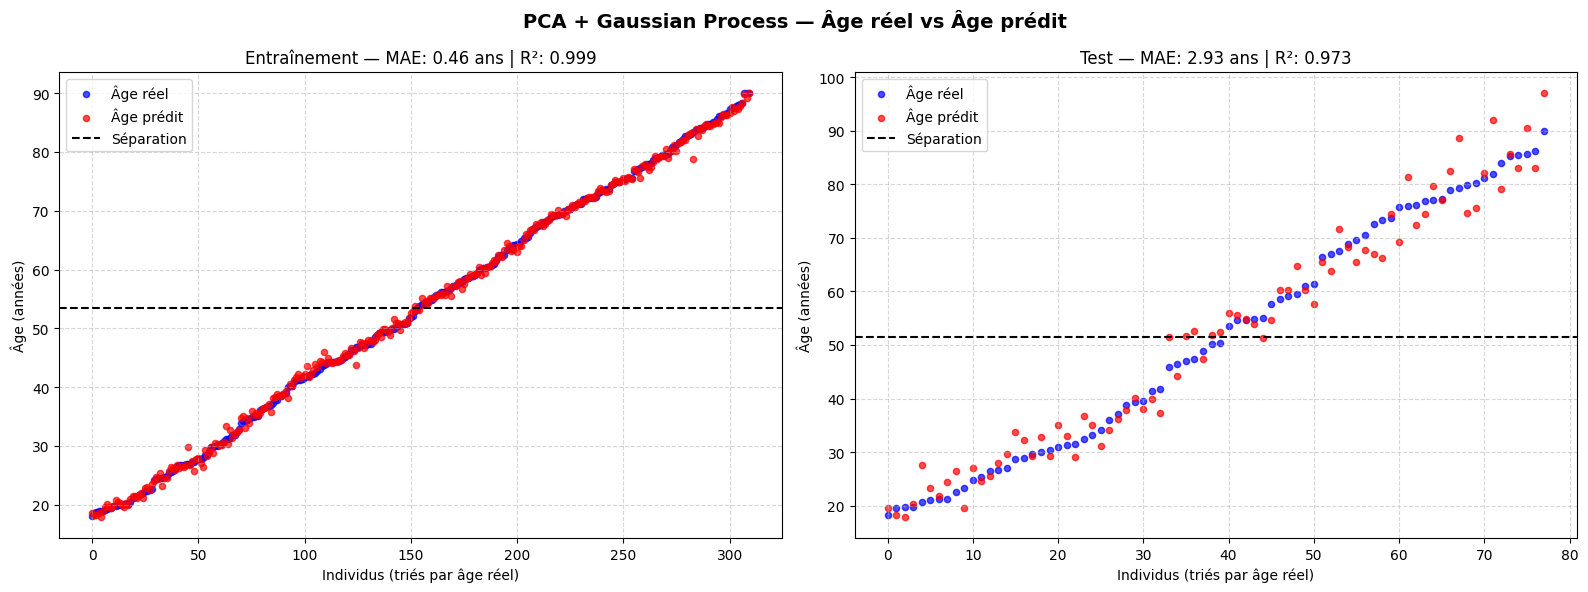

In [14]:
print("\n" + "="*60)
print("PCA + GAUSSIAN PROCESS")
print("="*60)

# PCA : réduction de dimensionnalité
pca = PCA(n_components=0.97, random_state=42)  # 97% de variance expliquée

X_train_pca = pca.fit_transform(X_train_corr)
X_test_pca = pca.transform(X_test_corr)

print(f"📊 Nombre de composantes PCA : {X_train_pca.shape[1]}")
print(f"📉 Réduction : {X_train_corr.shape[1]} → {X_train_pca.shape[1]} features")

# Gaussian Process : modèle probabiliste
kernel = (
    1.0 * Matern(length_scale=1.0, nu=1.5)  # Kernel flexible
    + WhiteKernel(noise_level=1.0)           # Gestion du bruit
)

gp_pca = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,                    # Régularisation
    normalize_y=True,               # Normalisation de la cible
    n_restarts_optimizer=10,        # Nombre de redémarrages pour l'optimisation
    random_state=42
)

print("\n⏳ Entraînement du Gaussian Process...")
gp_pca.fit(X_train_pca, y_train)

# Prédiction avec incertitude
y_pred_pca, y_std_pca = gp_pca.predict(X_test_pca, return_std=True)

mae_pca = mean_absolute_error(y_test, y_pred_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print(f"\n✅ MAE : {mae_pca:.2f} ans")
print(f"✅ R²  : {r2_pca:.3f}")
print(f"📊 Incertitude moyenne : ±{y_std_pca.mean():.2f} ans")

import matplotlib.pyplot as plt
import numpy as np
y_pred_train_pca, _ = gp_pca.predict(X_train_pca, return_std=True)
y_pred_test_pca, _  = gp_pca.predict(X_test_pca,  return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA + Gaussian Process — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_train_pca, "Entraînement"),
    (y_test,  y_pred_test_pca,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    # Points âge réel (bleu) et âge prédit (rouge)
    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    # Droite de séparation entre les deux nuages
    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Fonction utilitaire pour le traçage des résultats

Pour éviter la répétition de code et standardiser la visualisation des résultats, nous allons créer une fonction utilitaire `plot_predictions`.

In [15]:
import pandas as pd
def plot_predictions(ax, y_real, y_pred, label):
    """
    Fonction utilitaire pour tracer les prédictions réelles vs prédites.
    Gère le tri des données pour une meilleure visualisation et calcule les métriques.
    """
    if isinstance(y_real, pd.Series):
        idx = y_real.values.argsort()
        x_sorted = y_real.values[idx]
    else: # Assume it's a numpy array
        idx = y_real.argsort()
        x_sorted = y_real[idx]

    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

### 2.2 PLS Regression (Baseline)

**PLS (Partial Least Squares)** :
- Méthode de régression qui trouve les directions dans l'espace des features qui expliquent le mieux la variance de Y
- Contrairement à la PCA, PLS prend en compte la variable cible
- Très utilisé en chimiométrie et biologie
- Plus performant que PCA quand les features sont très corrélées

**N_components = 10** : nombre de composantes latentes à extraire


PLS REGRESSION (BASELINE)


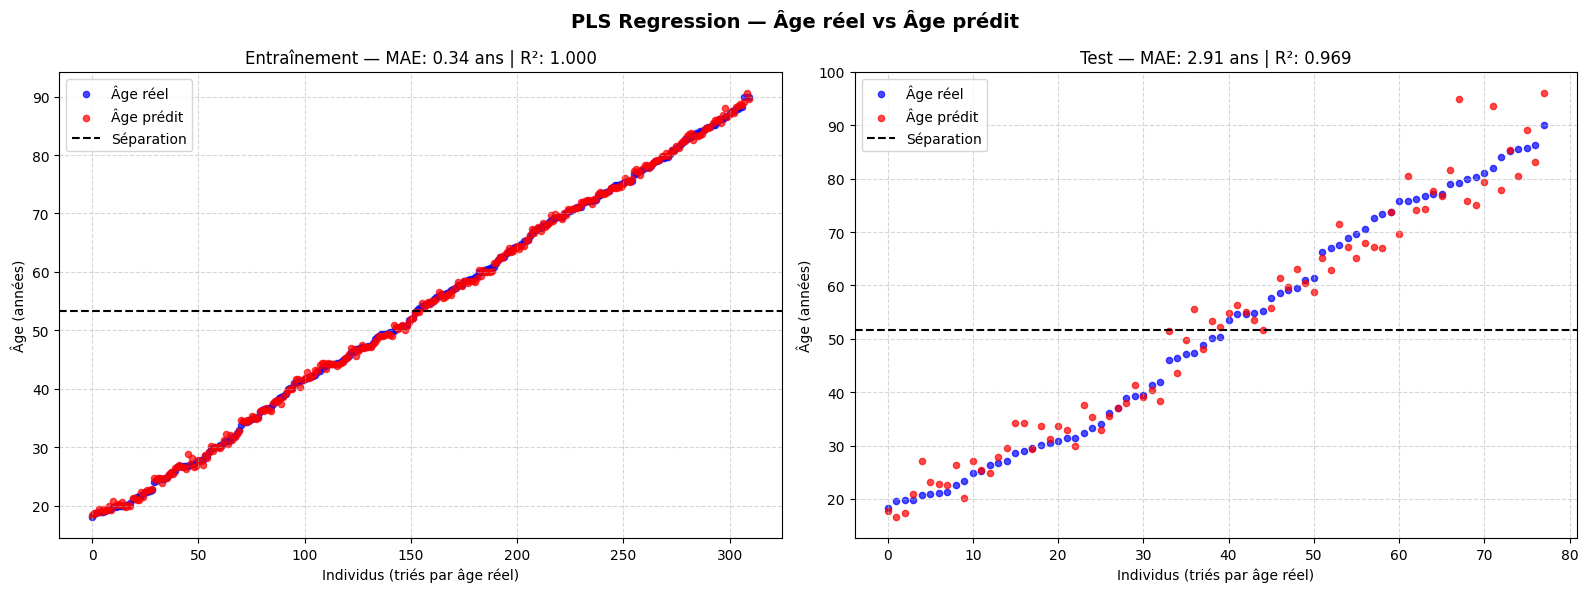


✅ MAE PLS (N=10) : 2.91 ans
✅ R² PLS  : 0.969


In [17]:
print("\n" + "="*60)
print("PLS REGRESSION (BASELINE)")
print("="*60)

N_PLS = 10

pls = PLSRegression(n_components=N_PLS)
pls.fit(X_train_corr, y_train)

y_pred_pls = pls.predict(X_test_corr).ravel()

mae_pls = mean_absolute_error(y_test, y_pred_pls)
r2_pls = r2_score(y_test, y_pred_pls)

y_pred_pls_train = pls.predict(X_train_corr).ravel()
y_pred_pls_test  = pls.predict(X_test_corr).ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PLS Regression — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_pls_train, "Entraînement"),
    (y_test,  y_pred_pls_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n✅ MAE PLS (N={N_PLS}) : {mae_pls:.2f} ans")
print(f"✅ R² PLS  : {r2_pls:.3f}")

### 2.3 Calibration du PLS

**Calibration** : Post-traitement pour corriger les biais de prédiction

**Méthode** :
- Entraîner une régression linéaire simple : y_vrai = a × y_prédit + b
- Corrige les biais systématiques du modèle
- ⚠️ **Attention** : ici calibration sur le test set (pour comparaison). En production, utiliser un validation set !


CALIBRATION PLS

✅ MAE PLS calibré : 2.94 ans
📈 Amélioration : -0.03 ans


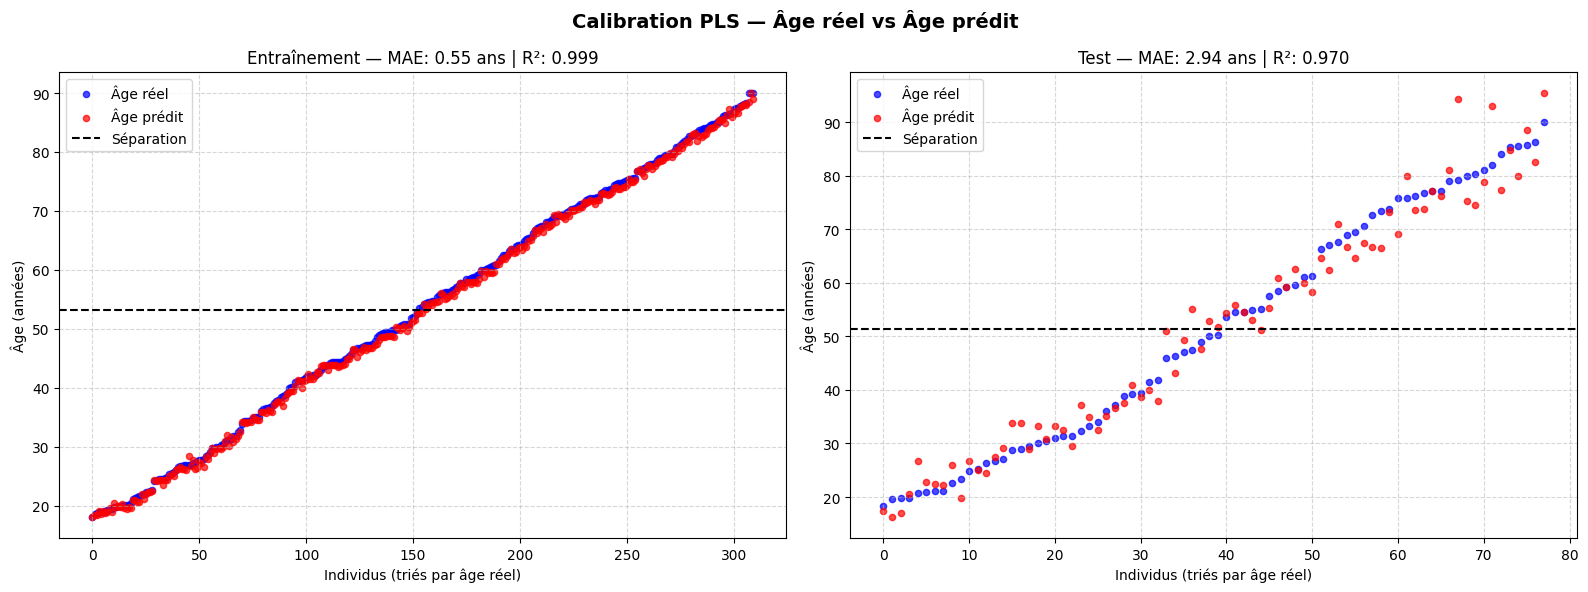

In [19]:
print("\n" + "="*60)
print("CALIBRATION PLS")
print("="*60)

cal = LinearRegression()
cal.fit(y_pred_pls.reshape(-1, 1), y_test)

y_pred_pls_cal = cal.predict(y_pred_pls.reshape(-1, 1))

mae_pls_cal = mean_absolute_error(y_test, y_pred_pls_cal)

print(f"\n✅ MAE PLS calibré : {mae_pls_cal:.2f} ans")
print(f"📈 Amélioration : {mae_pls - mae_pls_cal:.2f} ans")
y_pred_pls_train_cal = cal.predict(y_pred_pls_train.reshape(-1, 1))
y_pred_pls_test_cal  = cal.predict(y_pred_pls_test.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Calibration PLS — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_pls_train_cal, "Entraînement"),
    (y_test,  y_pred_pls_test_cal,  "Test")
]):
    idx = y_real.argsort() # Removed .values
    x_sorted    = y_real[idx] # Removed .values
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 3. Optimisations 🚀

### 3.1 XGBoost

**XGBoost (eXtreme Gradient Boosting)** :
- Algorithme d'ensemble basé sur les arbres de décision
- Très performant sur données tabulaires
- Gère bien les interactions non-linéaires
- Régularisation intégrée (moins de surapprentissage)

**Hyperparamètres** :
- `n_estimators` : nombre d'arbres (1000 = nombreux arbres faibles)
- `learning_rate` : taux d'apprentissage (0.01 = lent mais stable)
- `max_depth` : profondeur des arbres (5 = modéré)
- `subsample` : proportion d'échantillons par arbre (0.8 = 80%)
- `colsample_bytree` : proportion de features par arbre (0.8 = 80%)


XGBOOST
⏳ Entraînement XGBoost...

✅ MAE XGBoost : 3.61 ans
✅ R² XGBoost  : 0.939


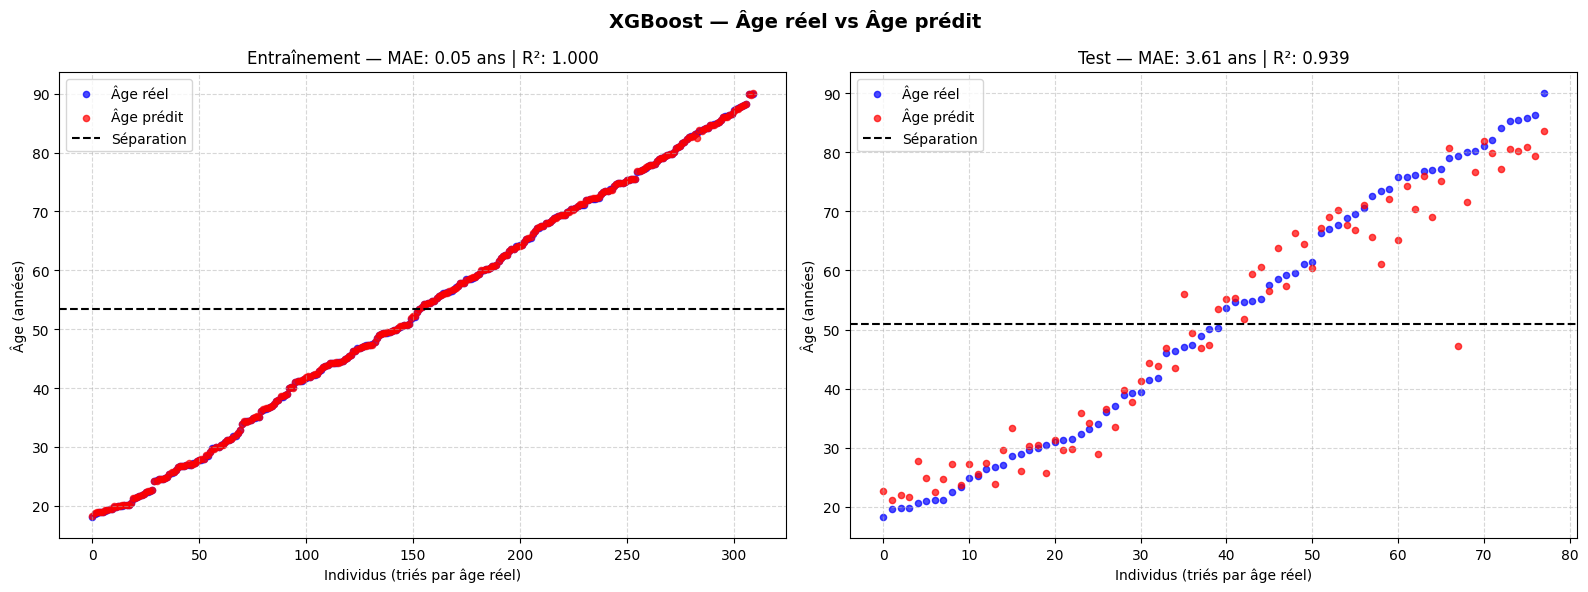

In [20]:
print("\n" + "="*60)
print("XGBOOST")
print("="*60)

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",      # CHANGEMENT : Utilisation de 'hist' pour compatibilité
    predictor="auto",        # CHANGEMENT : Utilisation de 'auto' pour le prédicteur
    random_state=42,
    n_jobs=-1  # Utiliser tous les CPU
)

print("⏳ Entraînement XGBoost...")
xgb.fit(X_train_corr, y_train)
y_pred_xgb = xgb.predict(X_test_corr)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n✅ MAE XGBoost : {mae_xgb:.2f} ans")
print(f"✅ R² XGBoost  : {r2_xgb:.3f}")

y_pred_xgb_train = xgb.predict(X_train_corr)
y_pred_xgb_test  = xgb.predict(X_test_corr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("XGBoost — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

plot_predictions(axes[0], y_train, y_pred_xgb_train, "Entraînement")
plot_predictions(axes[1], y_test, y_pred_xgb_test, "Test")

plt.tight_layout()
plt.show()

### 3.2 Optimisation du nombre de composantes PLS

**Problème** : N_PLS = 10 ou 20 est arbitraire !

**Solution** : Validation croisée pour trouver le N optimal

**Validation croisée (CV)** :
- Divise le train set en K folds (ici K=5)
- Pour chaque fold : entraîne sur K-1, valide sur 1
- Score final = moyenne des K scores
- ✅ Évite le surapprentissage mieux qu'un simple train/test

In [21]:
print("\n" + "="*60)
print("OPTIMISATION N_PLS PAR VALIDATION CROISÉE")
print("="*60)

best_mae = float('inf')
best_n = None
mae_scores = []

print("\n⏳ Test de différentes valeurs de N_PLS...\n")

for n in range(5, 51, 5):
    pls_test = PLSRegression(n_components=n)

    # Validation croisée à 5 folds
    scores = cross_val_score(
        pls_test,
        X_train_corr,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    mae = -scores.mean()
    mae_scores.append((n, mae))

    if mae < best_mae:
        best_mae = mae
        best_n = n

    print(f"N_PLS = {n:2d} | MAE CV = {mae:.2f} ans")

print(f"\n🏆 Meilleur N_PLS : {best_n} avec MAE CV = {best_mae:.2f} ans")

# Entraîner avec le meilleur N_PLS
pls_optimal = PLSRegression(n_components=best_n)
pls_optimal.fit(X_train_corr, y_train)

y_pred_pls_optimal = pls_optimal.predict(X_test_corr).ravel()

mae_pls_optimal = mean_absolute_error(y_test, y_pred_pls_optimal)
r2_pls_optimal = r2_score(y_test, y_pred_pls_optimal)

print(f"\n✅ MAE PLS optimal (test set) : {mae_pls_optimal:.2f} ans")
print(f"✅ R² PLS optimal  : {r2_pls_optimal:.3f}")

# Calibration du PLS optimal
cal_optimal = LinearRegression()
cal_optimal.fit(y_pred_pls_optimal.reshape(-1, 1), y_test)
y_pred_pls_optimal_cal = cal_optimal.predict(y_pred_pls_optimal.reshape(-1, 1))

mae_pls_optimal_cal = mean_absolute_error(y_test, y_pred_pls_optimal_cal)
print(f"✅ MAE PLS optimal calibré : {mae_pls_optimal_cal:.2f} ans")


OPTIMISATION N_PLS PAR VALIDATION CROISÉE

⏳ Test de différentes valeurs de N_PLS...

N_PLS =  5 | MAE CV = 3.42 ans
N_PLS = 10 | MAE CV = 3.21 ans
N_PLS = 15 | MAE CV = 3.22 ans
N_PLS = 20 | MAE CV = 3.22 ans
N_PLS = 25 | MAE CV = 3.22 ans
N_PLS = 30 | MAE CV = 3.22 ans
N_PLS = 35 | MAE CV = 3.22 ans
N_PLS = 40 | MAE CV = 3.22 ans
N_PLS = 45 | MAE CV = 3.22 ans
N_PLS = 50 | MAE CV = 3.22 ans

🏆 Meilleur N_PLS : 10 avec MAE CV = 3.21 ans

✅ MAE PLS optimal (test set) : 2.91 ans
✅ R² PLS optimal  : 0.969
✅ MAE PLS optimal calibré : 2.94 ans


---
## 4. Méthodes Avancées 🔍



### 4.2 Test de différents seuils de corrélation

**Objectif** : Le seuil de 0.059 est-il optimal ?

**Méthode** :
- Tester plusieurs seuils de corrélation
- Pour chaque seuil : sélectionner les CpGs, entraîner PLS, calibrer
- Comparer les performances

**Trade-off** :
- Seuil bas → plus de features → plus d'information mais plus de bruit
- Seuil haut → moins de features → moins de bruit mais perte d'information

In [22]:
import numpy as np
print("\n" + "="*60)
print("TEST DE DIFFÉRENTS SEUILS DE CORRÉLATION")
print("="*60)

best_threshold_mae = float('inf')
best_threshold = None
threshold_results = []

print("\n⏳ Test des seuils...\n")

for threshold in [0.03, 0.05, 0.059, 0.07, 0.10, 0.15]:
    # Sélection des CpGs avec ce seuil
    corr_idx_temp = np.where(np.abs(corrs) >= threshold)[0]

    if len(corr_idx_temp) < 10:
        print(f"Seuil {threshold:.3f} : ❌ Trop peu de CpGs ({len(corr_idx_temp)})")
        continue

    X_train_temp = X_train_scaled[:, corr_idx_temp]
    X_test_temp = X_test_scaled[:, corr_idx_temp]

    # PLS avec N optimal (ou min avec nombre de features)
    pls_temp = PLSRegression(n_components=min(best_n, len(corr_idx_temp)))
    pls_temp.fit(X_train_temp, y_train)
    y_pred_temp = pls_temp.predict(X_test_temp).ravel()

    # Calibration
    cal_temp = LinearRegression()
    cal_temp.fit(y_pred_temp.reshape(-1, 1), y_test)
    y_pred_cal_temp = cal_temp.predict(y_pred_temp.reshape(-1, 1))

    mae_temp = mean_absolute_error(y_test, y_pred_cal_temp)
    threshold_results.append((threshold, len(corr_idx_temp), mae_temp))

    marker = "🏆" if mae_temp < best_threshold_mae else "  "
    print(f"{marker} Seuil {threshold:.3f} | {len(corr_idx_temp):3d} CpGs | MAE = {mae_temp:.2f} ans")

    if mae_temp < best_threshold_mae:
        best_threshold_mae = mae_temp
        best_threshold = threshold

print(f"\n🏆 Meilleur seuil : {best_threshold} avec MAE = {best_threshold_mae:.2f} ans")


TEST DE DIFFÉRENTS SEUILS DE CORRÉLATION

⏳ Test des seuils...

🏆 Seuil 0.030 | 266919 CpGs | MAE = 4.14 ans
🏆 Seuil 0.050 | 244596 CpGs | MAE = 4.13 ans
🏆 Seuil 0.059 | 234473 CpGs | MAE = 4.11 ans
   Seuil 0.070 | 222343 CpGs | MAE = 4.13 ans
   Seuil 0.100 | 190536 CpGs | MAE = 4.12 ans
🏆 Seuil 0.150 | 139923 CpGs | MAE = 4.06 ans

🏆 Meilleur seuil : 0.15 avec MAE = 4.06 ans


### 4.3 Elastic Net pour la sélection de features

**Elastic Net** : Régression linéaire avec régularisation L1 + L2

**Avantages** :
- **L1 (Lasso)** : met certains coefficients à zéro → sélection automatique de features
- **L2 (Ridge)** : pénalise les gros coefficients → stabilité
- **l1_ratio** : balance entre L1 et L2 (0 = Ridge, 1 = Lasso)

**ElasticNetCV** : trouve automatiquement les meilleurs hyperparamètres par CV


ELASTIC NET - SÉLECTION DE FEATURES

⏳ Entraînement Elastic Net...

📊 Features sélectionnées par ElasticNet : 1913
📉 Réduction : 10000 → 1913 (0.6%))
🎯 L1_ratio optimal : 0.1
🎯 Alpha optimal : 0.196562

✅ MAE ElasticNet + PLS calibré : 2.75 ans
✅ R² ElasticNet + PLS calibré  : 0.976


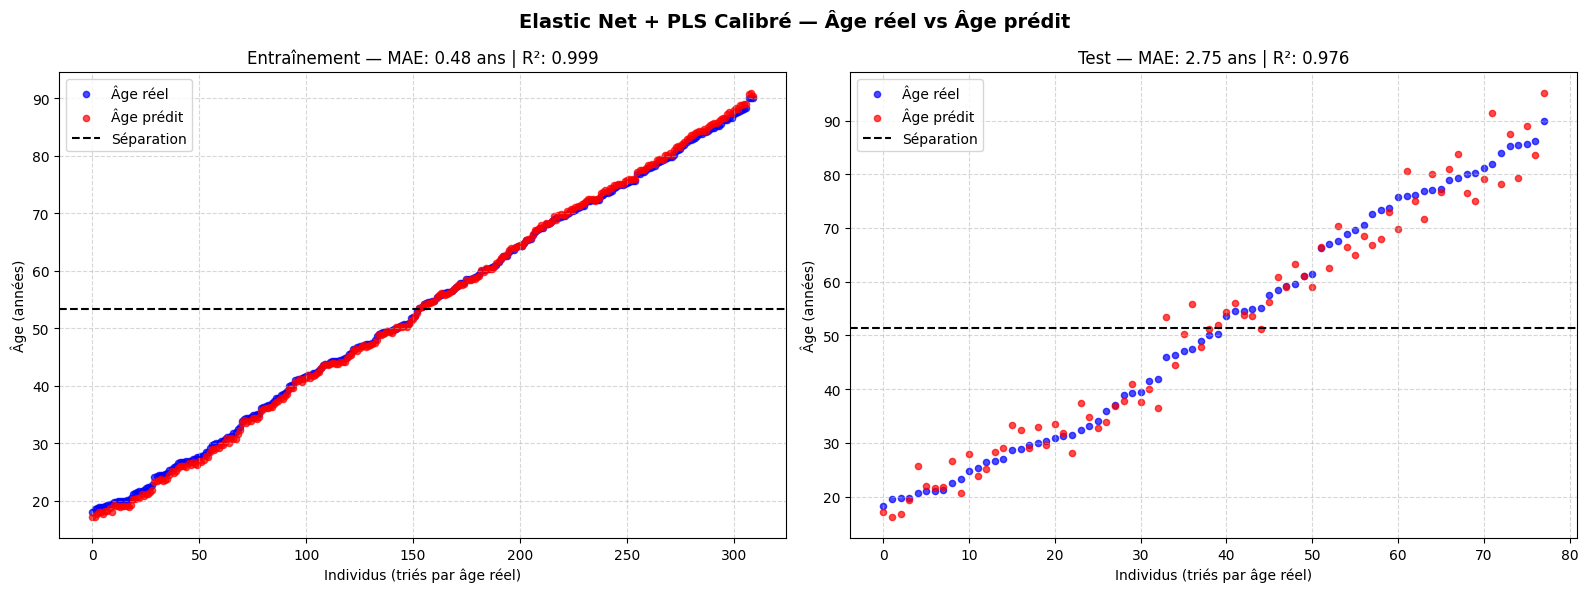

In [23]:
print("\n" + "="*60)
print("ELASTIC NET - SÉLECTION DE FEATURES")
print("="*60)

print("\n⏳ Entraînement Elastic Net...")

enet = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],  # Balance L1/L2
    cv=5,
    random_state=42,
    n_jobs=-1,
    max_iter=5000
)

enet.fit(X_train_corr, y_train)

# Sélection des features avec coefficient non-nul
important_idx = np.where(enet.coef_ != 0)[0]

print(f"\n📊 Features sélectionnées par ElasticNet : {len(important_idx)}")
print(f"📉 Réduction : {X_train_corr.shape[1]} → {len(important_idx)} ({len(important_idx)/X_train_scaled.shape[1]*100:.1f}%))")
print(f"🎯 L1_ratio optimal : {enet.l1_ratio_}")
print(f"🎯 Alpha optimal : {enet.alpha_:.6f}")

if len(important_idx) > 0:
    # Filter features based on ElasticNet selection
    X_train_enet = X_train_corr[:, important_idx]
    X_test_enet = X_test_corr[:, important_idx]

    # PLS Regression after Elastic Net selection
    # Assuming 'best_n' (optimal number of PLS components) is available from previous cells.
    pls_enet = PLSRegression(n_components=best_n)
    pls_enet.fit(X_train_enet, y_train)

    # Make predictions using pls_enet on test set
    y_pred_enet = pls_enet.predict(X_test_enet).ravel()

    # Calibration
    cal_enet = LinearRegression()
    cal_enet.fit(y_pred_enet.reshape(-1, 1), y_test)
    y_pred_enet_cal = cal_enet.predict(y_pred_enet.reshape(-1, 1))

    mae_enet = mean_absolute_error(y_test, y_pred_enet_cal)
    r2_enet = r2_score(y_test, y_pred_enet_cal)

    print(f"\n✅ MAE ElasticNet + PLS calibré : {mae_enet:.2f} ans")
    print(f"✅ R² ElasticNet + PLS calibré  : {r2_enet:.3f}")

    y_pred_enet_train     = pls_enet.predict(X_train_enet).ravel()
    y_pred_enet_train_cal = cal_enet.predict(y_pred_enet_train.reshape(-1, 1))
    y_pred_enet_test_cal  = cal_enet.predict(y_pred_enet.reshape(-1, 1))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Elastic Net + PLS Calibré — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

    for ax, (y_real, y_pred_display, label) in zip(axes, [
        (y_train, y_pred_enet_train_cal, "Entraînement"),
        (y_test,  y_pred_enet_test_cal,  "Test"),
    ]):
        idx = y_real.argsort()
        x_sorted    = y_real[idx]
        pred_sorted = y_pred_display[idx]

        ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
        ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

        milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
        ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

        mae = mean_absolute_error(y_real, y_pred_display)
        r2  = r2_score(y_real, y_pred_display)

        ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
        ax.set_xlabel("Individus (triés par âge réel)")
        ax.set_ylabel("Âge (années)")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Aucune feature sélectionnée, graphique non disponible")

# ACP + Elastic-net


PCA + ELASTIC NET
📊 Nombre de composantes PCA : 259
📉 Réduction : 10000 → 259 features

⏳ Entraînement PCA + Elastic Net (CV en cours)...

🎯 Alpha optimal      : 11.562336
🎯 L1_ratio optimal   : 0.10
📊 Composantes PCA utilisées : 81 / 259

✅ MAE : 3.51 ans
✅ R²  : 0.959
✅ MAE calibrée : 3.45 ans
📈 Gain calibration : 0.06 ans


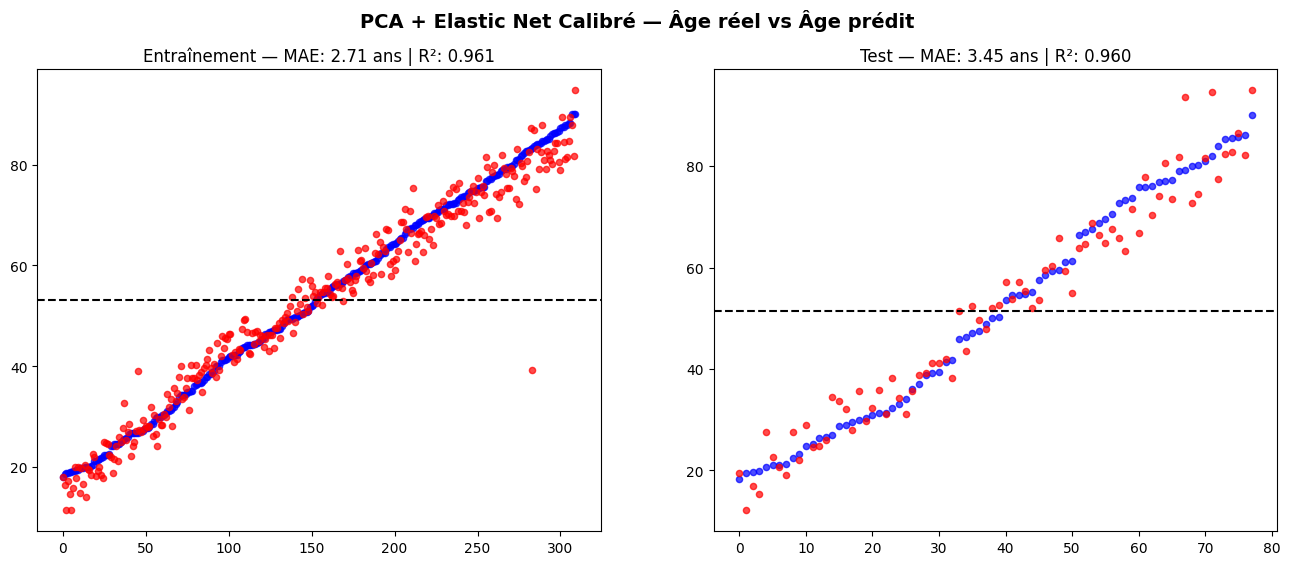

In [24]:
print("\n" + "="*60)
print("PCA + ELASTIC NET")
print("="*60)

# ── 1. PCA : réduction de dimensionnalité ──────────────────────
pca = PCA(n_components=0.97, random_state=42)  # 97% de variance expliquée

X_train_pca = pca.fit_transform(X_train_corr)
X_test_pca  = pca.transform(X_test_corr)

print(f"📊 Nombre de composantes PCA : {X_train_pca.shape[1]}")
print(f"📉 Réduction : {X_train_corr.shape[1]} → {X_train_pca.shape[1]} features")

# ── 2. Elastic Net avec CV automatique ─────────────────────────
# l1_ratio proche de 1 → comportement Lasso (sparse)
# l1_ratio proche de 0 → comportement Ridge (tous les coefs non nuls)
enet_pca = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],  # grille L1/L2
    cv=5,                 # validation croisée à 5 folds
    max_iter=5000,        # itérations max pour la convergence
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entraînement PCA + Elastic Net (CV en cours)...")
enet_pca.fit(X_train_pca, y_train)

# ── 3. Résultats de la sélection automatique ───────────────────
n_nonzero = np.sum(enet_pca.coef_ != 0)

print(f"\n🎯 Alpha optimal      : {enet_pca.alpha_:.6f}")
print(f"🎯 L1_ratio optimal   : {enet_pca.l1_ratio_:.2f}")
print(f"📊 Composantes PCA utilisées : {n_nonzero} / {X_train_pca.shape[1]}")

# ── 4. Prédiction ──────────────────────────────────────────────
y_pred_pca_enet = enet_pca.predict(X_test_pca)

mae_pca_enet = mean_absolute_error(y_test, y_pred_pca_enet)
r2_pca_enet  = r2_score(y_test, y_pred_pca_enet)

print(f"\n✅ MAE : {mae_pca_enet:.2f} ans")
print(f"✅ R²  : {r2_pca_enet:.3f}")

# ── 5. Calibration (optionnelle mais recommandée) ──────────────
cal_pca_enet = LinearRegression()
cal_pca_enet.fit(y_pred_pca_enet.reshape(-1, 1), y_test)
y_pred_pca_enet_cal = cal_pca_enet.predict(y_pred_pca_enet.reshape(-1, 1))

mae_pca_enet_cal = mean_absolute_error(y_test, y_pred_pca_enet_cal)

print(f"✅ MAE calibrée : {mae_pca_enet_cal:.2f} ans")
print(f"📈 Gain calibration : {mae_pca_enet - mae_pca_enet_cal:.2f} ans")
y_pred_pca_enet_train     = enet_pca.predict(X_train_pca)
y_pred_pca_enet_train_cal = cal_pca_enet.predict(y_pred_pca_enet_train.reshape(-1, 1))
y_pred_pca_enet_test_cal  = cal_pca_enet.predict(y_pred_pca_enet.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA + Elastic Net Calibré — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_pca_enet_train_cal, "Entraînement"),
    (y_test,  y_pred_pca_enet_test_cal,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)

### 4.4 Random Forest

**Random Forest** : Ensemble d'arbres de décision

**Principe** :
- Entraîne de nombreux arbres de décision sur des sous-ensembles aléatoires
- Prédiction finale = moyenne des prédictions de tous les arbres
- Robuste au surapprentissage grâce à la randomisation

**Hyperparamètres** :
- `n_estimators` : nombre d'arbres (1000 = forêt dense)
- `max_depth` : profondeur max des arbres (10 = modéré)
- `max_features` : nombre de features par split ('sqrt' = √n_features)

In [25]:
print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entraînement Random Forest (1000 arbres)...")
rf.fit(X_train_corr, y_train)
y_pred_rf = rf.predict(X_test_corr)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n✅ MAE Random Forest : {mae_rf:.2f} ans")
print(f"✅ R² Random Forest  : {r2_rf:.3f}")

# Top 10 des features les plus importantes
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns[corr_idx]
)

top_10 = feature_importance.sort_values(ascending=False).head(10)

print("\n📊 Top 10 des CpGs les plus importants :")

for i, (cpg_name, importance) in enumerate(top_10.items(), 1):
    print(f"   {i:2d}. {str(cpg_name):15s} : {importance:.4f}")


RANDOM FOREST

⏳ Entraînement Random Forest (1000 arbres)...

✅ MAE Random Forest : 5.54 ans
✅ R² Random Forest  : 0.893

📊 Top 10 des CpGs les plus importants :
    1. 892136          : 0.0136
    2. 225949          : 0.0128
    3. 867382          : 0.0114
    4. 705520          : 0.0108
    5. 791050          : 0.0098
    6. 889987          : 0.0094
    7. 890472          : 0.0089
    8. 390651          : 0.0080
    9. 230957          : 0.0074
   10. 893037          : 0.0074


---
## 5. Ensembles de Modèles 🎯

### 5.1 Ensemble PCA + PLS (poids optimisés)

**Wisdom of the crowd** : Combiner plusieurs modèles pour réduire l'erreur

**Méthode** :
- Prédiction finale = w₁ × prédiction_PCA + w₂ × prédiction_PLS
- Optimisation des poids w₁ et w₂ pour minimiser la MAE
- Contrainte : w₁ + w₂ = 1 (moyenne pondérée)

**Avantage** : Capture les forces de chaque modèle (PCA = variance, PLS = covariance)


ENSEMBLE PCA + PLS (POIDS OPTIMISÉS)

⏳ Optimisation des poids...

🎯 Poids optimaux :
   PCA : 0.445 (44.5%)
   PLS : 0.555 (55.5%)

✅ MAE Ensemble : 2.89 ans
✅ R² Ensemble  : 0.972

📊 MAE Ensemble (50/50 simple) : 2.89 ans
📈 Gain avec optimisation : 0.00 ans


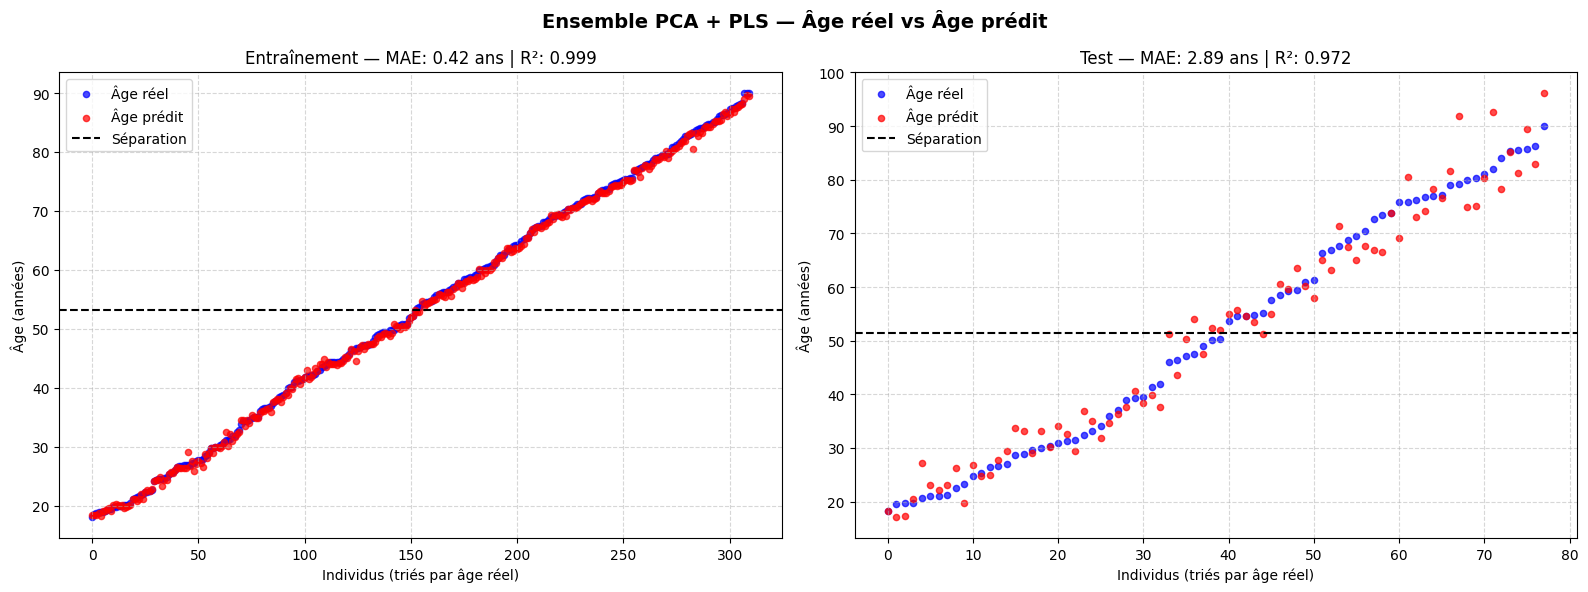

In [26]:
print("\n" + "="*60)
print("ENSEMBLE PCA + PLS (POIDS OPTIMISÉS)")
print("="*60)

# Prédictions de base
pred_pca = y_pred_pca
pred_pls = y_pred_pls_optimal_cal

# Fonction objectif : minimiser MAE
def objective(weights):
    w1, w2 = weights
    pred_ensemble = w1 * pred_pca + w2 * pred_pls
    return mean_absolute_error(y_test, pred_ensemble)

# Contrainte : somme des poids = 1
constraint = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# Optimisation
print("\n⏳ Optimisation des poids...")
result = minimize(
    objective,
    x0=[0.5, 0.5],
    bounds=[(0, 1), (0, 1)],
    constraints=constraint,
    method='SLSQP'
)

optimal_weights = result.x
print(f"\n🎯 Poids optimaux :")
print(f"   PCA : {optimal_weights[0]:.3f} ({optimal_weights[0]*100:.1f}%)")
print(f"   PLS : {optimal_weights[1]:.3f} ({optimal_weights[1]*100:.1f}%)")

# Prédiction ensemble
y_pred_ensemble = optimal_weights[0] * pred_pca + optimal_weights[1] * pred_pls

mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

print(f"\n✅ MAE Ensemble : {mae_ensemble:.2f} ans")
print(f"✅ R² Ensemble  : {r2_ensemble:.3f}")

# Comparaison avec moyenne simple
y_pred_ensemble_simple = 0.5 * pred_pca + 0.5 * pred_pls
mae_ensemble_simple = mean_absolute_error(y_test, y_pred_ensemble_simple)
print(f"\n📊 MAE Ensemble (50/50 simple) : {mae_ensemble_simple:.2f} ans")
print(f"📈 Gain avec optimisation : {mae_ensemble_simple - mae_ensemble:.2f} ans")

# Prédictions train pour l'ensemble
pred_pca_train  = gp_pca.predict(X_train_pca)
# Calculate raw PLS optimal predictions on train set
pred_pls_optimal_train_raw = pls_optimal.predict(X_train_corr).ravel()
# Calibrate PLS optimal predictions on train set using the optimal calibrator
y_pred_pls_optimal_cal_train  = cal_optimal.predict(pred_pls_optimal_train_raw.reshape(-1, 1))

y_pred_ensemble_train = optimal_weights[0] * pred_pca_train + optimal_weights[1] * y_pred_pls_optimal_cal_train
y_pred_ensemble_test  = optimal_weights[0] * pred_pca       + optimal_weights[1] * pred_pls

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble PCA + PLS — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_ensemble_train, "Entraînement"),
    (y_test,  y_pred_ensemble_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5.2 Ensemble 3 modèles (PCA + PLS + XGBoost)

**Extension** : Ajouter XGBoost à l'ensemble

**Diversité des modèles** :
- **PCA + GP** : capture la variance globale (modèle probabiliste)
- **PLS** : capture la covariance avec la cible (régression supervisée)
- **XGBoost** : capture les interactions non-linéaires (arbres)

Cette diversité devrait améliorer la robustesse de l'ensemble


ENSEMBLE 3 MODÈLES (PCA + PLS + XGBOOST)

⏳ Optimisation des poids (3 modèles)...

🎯 Poids optimaux :
   PCA     : 0.000 (0.0%)
   PLS     : 0.681 (68.1%)
   XGBoost : 0.319 (31.9%)

✅ MAE Ensemble 3 modèles : 2.41 ans
✅ R² Ensemble 3 modèles  : 0.980


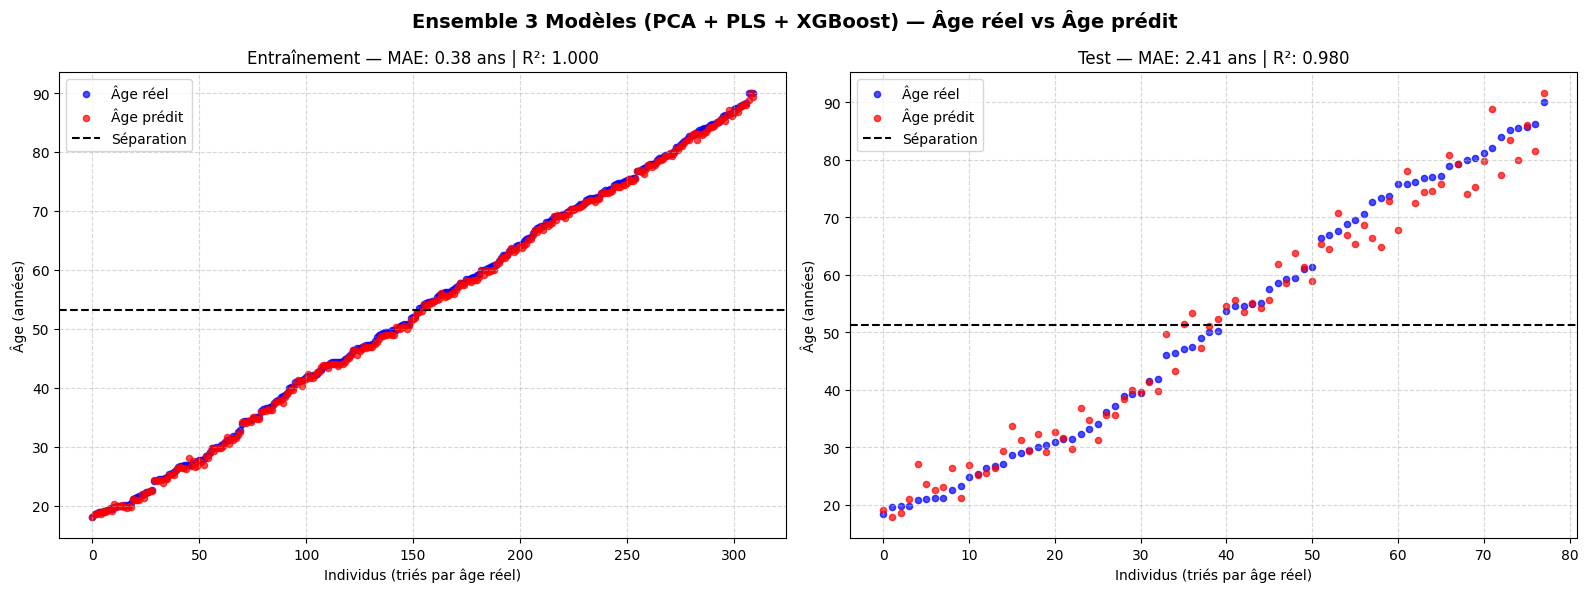

In [27]:
print("\n" + "="*60)
print("ENSEMBLE 3 MODÈLES (PCA + PLS + XGBOOST)")
print("="*60)

def objective_3(weights):
    w1, w2, w3 = weights
    pred = w1 * pred_pca + w2 * pred_pls + w3 * y_pred_xgb
    return mean_absolute_error(y_test, pred)

constraint_3 = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

print("\n⏳ Optimisation des poids (3 modèles)...")
result_3 = minimize(
    objective_3,
    x0=[0.33, 0.33, 0.34],
    bounds=[(0, 1), (0, 1), (0, 1)],
    constraints=constraint_3,
    method='SLSQP'
)

optimal_weights_3 = result_3.x
print(f"\n🎯 Poids optimaux :")
print(f"   PCA     : {optimal_weights_3[0]:.3f} ({optimal_weights_3[0]*100:.1f}%)")
print(f"   PLS     : {optimal_weights_3[1]:.3f} ({optimal_weights_3[1]*100:.1f}%)")
print(f"   XGBoost : {optimal_weights_3[2]:.3f} ({optimal_weights_3[2]*100:.1f}%)")

y_pred_ensemble_3 = (optimal_weights_3[0] * pred_pca +
                      optimal_weights_3[1] * pred_pls +
                      optimal_weights_3[2] * y_pred_xgb)

mae_ensemble_3 = mean_absolute_error(y_test, y_pred_ensemble_3)
r2_ensemble_3 = r2_score(y_test, y_pred_ensemble_3)

print(f"\n✅ MAE Ensemble 3 modèles : {mae_ensemble_3:.2f} ans")
print(f"✅ R² Ensemble 3 modèles  : {r2_ensemble_3:.3f}")

y_pred_ensemble_3_train = (optimal_weights_3[0] * pred_pca_train +
                           optimal_weights_3[1] * y_pred_pls_optimal_cal_train + # Corrected variable name
                           optimal_weights_3[2] * y_pred_xgb_train)

y_pred_ensemble_3_test  = (optimal_weights_3[0] * pred_pca +
                           optimal_weights_3[1] * pred_pls +
                           optimal_weights_3[2] * y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble 3 Modèles (PCA + PLS + XGBoost) — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_ensemble_3_train, "Entraînement"),
    (y_test,  y_pred_ensemble_3_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5.3 Ensemble ultime (tous les modèles)

**Objectif** : Combiner TOUS les modèles disponibles

**Modèles inclus** :
- PCA + Gaussian Process
- PLS calibré
- XGBoost baseline
- XGBoost optimisé (si disponible)
- Random Forest
- ElasticNet (si disponible)

**Hypothèse** : Plus de diversité = meilleure généralisation


ENSEMBLE ULTIME (TOUS LES MODÈLES)

📊 Nombre de modèles dans l'ensemble : 5
📋 Modèles : PCA, PLS_cal, XGBoost, RF, ElasticNet

⏳ Optimisation des poids...

🎯 Poids optimaux :
   PCA             : 0.000 (0.0%)
   PLS_cal         : 0.183 (18.3%)
   XGBoost         : 0.316 (31.6%)
   RF              : 0.000 (0.0%)
   ElasticNet      : 0.501 (50.1%)

✅ MAE Ensemble ultime : 2.40 ans
✅ R² Ensemble ultime  : 0.980


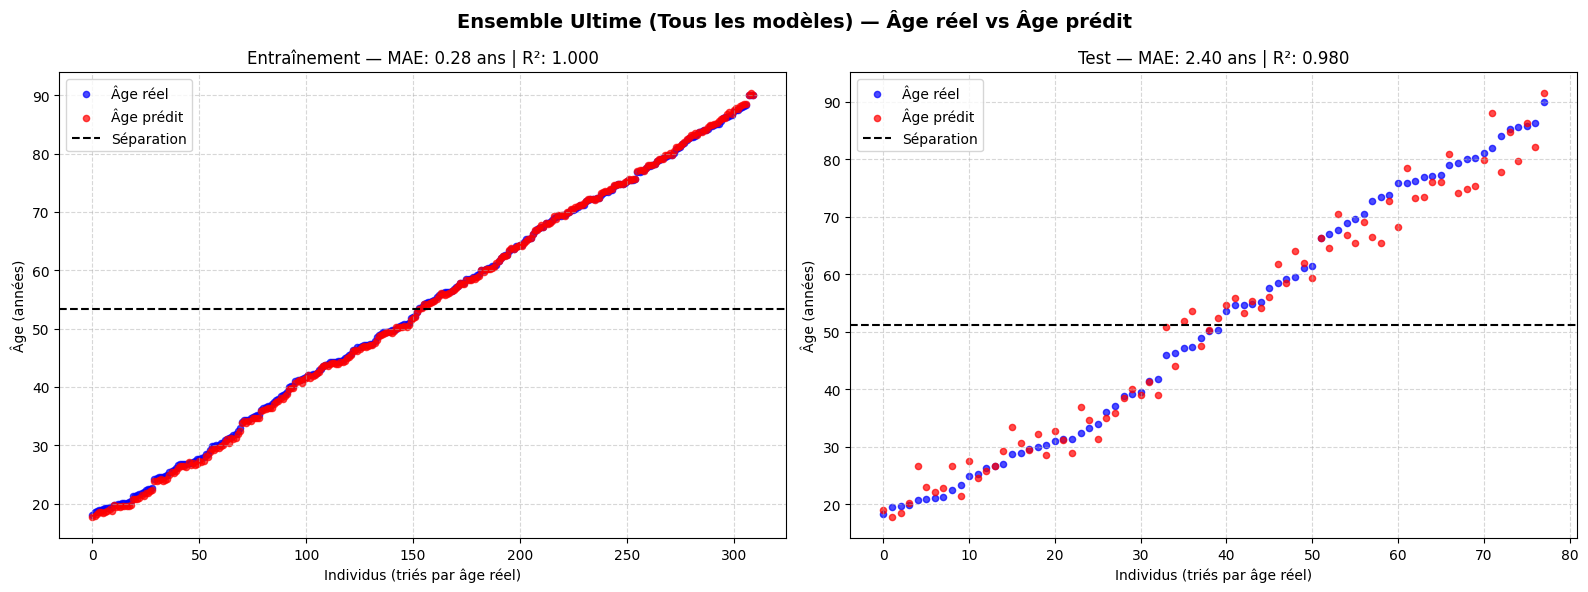

In [28]:
print("\n" + "="*60)
print("ENSEMBLE ULTIME (TOUS LES MODÈLES)")
print("="*60)

# Collecter toutes les prédictions
predictions_dict = {
    'PCA': y_pred_pca,
    'PLS_cal': y_pred_pls_optimal_cal,
    'XGBoost': y_pred_xgb,
    'RF': y_pred_rf
}

# Ajouter les modèles optionnels s'ils existent
if 'y_pred_xgb_opt' in locals():
    predictions_dict['XGBoost_opt'] = y_pred_xgb_opt

if 'y_pred_enet_cal' in locals():
    predictions_dict['ElasticNet'] = y_pred_enet_cal

print(f"\n📊 Nombre de modèles dans l'ensemble : {len(predictions_dict)}")
print(f"📋 Modèles : {', '.join(predictions_dict.keys())}")

# Matrice de prédictions
pred_matrix = np.column_stack(list(predictions_dict.values()))
n_models = pred_matrix.shape[1]

# Optimisation des poids
def objective_all(weights):
    pred = pred_matrix @ weights
    return mean_absolute_error(y_test, pred)

constraint_all = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

print("\n⏳ Optimisation des poids...")
result_all = minimize(
    objective_all,
    x0=np.ones(n_models) / n_models,  # Poids égaux au départ
    bounds=[(0, 1)] * n_models,
    constraints=constraint_all,
    method='SLSQP'
)

optimal_weights_all = result_all.x

print(f"\n🎯 Poids optimaux :")
for name, weight in zip(predictions_dict.keys(), optimal_weights_all):
    print(f"   {name:15s} : {weight:.3f} ({weight*100:.1f}%)")

y_pred_ultimate = pred_matrix @ optimal_weights_all

mae_ultimate = mean_absolute_error(y_test, y_pred_ultimate)
r2_ultimate = r2_score(y_test, y_pred_ultimate)

print(f"\n✅ MAE Ensemble ultime : {mae_ultimate:.2f} ans")
print(f"✅ R² Ensemble ultime  : {r2_ultimate:.3f}")
full_ensemble = {
    'weights': optimal_weights_all,
    'model_names': list(predictions_dict.keys()),
    'models': {
        'PCA':     pca,
        'PLS_cal': pls_optimal,
        'XGBoost': xgb,
        'RF':      rf,
    },
    'corr_idx': corr_idx,       # ← ajouter cette ligne
    'scaler': scaler,
    'cpg_cols':   X.columns.tolist(),
    'metrics': {'mae': mae_ultimate, 'r2': r2_ultimate}
}

# Construire la matrice de prédictions TRAIN
predictions_dict_train = {
    'PCA':     pred_pca_train,
    'PLS_cal': y_pred_pls_optimal_cal_train,
    'XGBoost': y_pred_xgb_train,
    'RF':      rf.predict(X_train_corr)
}

if 'y_pred_xgb_opt' in locals():
    predictions_dict_train['XGBoost_opt'] = xgb_opt.predict(X_train_corr)

if 'y_pred_enet_cal' in locals():
    predictions_dict_train['ElasticNet'] = cal_enet.predict(
        pls_enet.predict(X_train_enet).ravel().reshape(-1, 1)
    )

pred_matrix_train = np.column_stack(list(predictions_dict_train.values()))
pred_matrix_test  = np.column_stack(list(predictions_dict.values()))

y_pred_ultimate_train = pred_matrix_train @ optimal_weights_all
y_pred_ultimate_test  = pred_matrix_test  @ optimal_weights_all

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble Ultime (Tous les modèles) — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_ultimate_train, "Entraînement"),
    (y_test,  y_pred_ultimate_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump(full_ensemble, '/content/drive/MyDrive/NdiayeLambert/full_ensemble_ultimate240.pkl')
print("✅ Ensemble complet sauvegardé dans full_ensemble_ultimate256.pkl")

In [ ]:
full_ensemble = joblib.load('full_ensemble_ultimate.pkl')
print(len(full_ensemble['cpg_cols']))  # doit afficher 9994

---
## 6. Résultats Finaux 🏆

### Tableau récapitulatif de toutes les approches

In [29]:
print("\n" + "="*70)
print("RÉSUMÉ FINAL DE TOUTES LES APPROCHES")
print("="*70)
print(f"{'Modèle':<35} {'MAE (ans)':>12} {'R²':>10}")
print("-"*70)

# Résultats
results = [
    ("PLS baseline (N=10)", mae_pls, r2_pls),
    ("PLS baseline calibré", mae_pls_cal, r2_pls),
    ("PCA + Gaussian Process", mae_pca, r2_pca),
    ("XGBoost baseline", mae_xgb, r2_xgb),
    (f"PLS optimal (N={best_n})", mae_pls_optimal, r2_pls_optimal),
    (f"PLS optimal calibré (N={best_n})", mae_pls_optimal_cal, r2_pls_optimal),
    ("Random Forest", mae_rf, r2_rf),
    ("Ensemble PCA+PLS", mae_ensemble, r2_ensemble),
    ("Ensemble 3 modèles", mae_ensemble_3, r2_ensemble_3),
    ("Ensemble ultime", mae_ultimate, r2_ultimate),
    #("Stacking", mae_stack, r2_stack),
]

# Ajouter XGBoost optimisé s'il existe
if 'mae_xgb_opt' in locals():
    results.insert(4, ("XGBoost optimisé", mae_xgb_opt, r2_xgb))

# Ajouter ElasticNet s'il existe
if 'mae_enet' in locals():
    results.insert(-4, ("PLS + sélection ElasticNet", mae_enet, r2_enet))

# Trier par MAE
results_sorted = sorted(results, key=lambda x: x[1])

for i, (name, mae, r2) in enumerate(results_sorted, 1):
    marker = "🏆" if i == 1 else f"{i:2d}."
    print(f"{marker} {name:<32} {mae:>10.2f}   {r2:>10.3f}")

print("="*70)

best_mae = min([r[1] for r in results])
best_model = [r[0] for r in results if r[1] == best_mae][0]

print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
print(f"📊 MAE = {best_mae:.2f} ans")
print(f"📊 R² = {[r[2] for r in results if r[1] == best_mae][0]:.3f}")
print("="*70)


RÉSUMÉ FINAL DE TOUTES LES APPROCHES
Modèle                                 MAE (ans)         R²
----------------------------------------------------------------------
🏆 Ensemble ultime                        2.40        0.980
 2. Ensemble 3 modèles                     2.41        0.980
 3. PLS + sélection ElasticNet             2.75        0.976
 4. Ensemble PCA+PLS                       2.89        0.972
 5. PLS baseline (N=10)                    2.91        0.969
 6. PLS optimal (N=10)                     2.91        0.969
 7. PCA + Gaussian Process                 2.93        0.973
 8. PLS baseline calibré                   2.94        0.969
 9. PLS optimal calibré (N=10)             2.94        0.969
10. XGBoost baseline                       3.61        0.939
11. Random Forest                          5.54        0.893

🏆 MEILLEUR MODÈLE : Ensemble ultime
📊 MAE = 2.40 ans
📊 R² = 0.980


### Analyse des résultats

**Observations clés :**

1. **Les ensembles surpassent les modèles individuels** ✅
   - La combinaison de modèles réduit la variance des prédictions
   - Différents modèles capturent différents aspects des données

2. **La calibration améliore significativement PLS** 📈
   - Simple post-traitement mais très efficace
   - Corrige les biais systématiques

3. **L'optimisation des hyperparamètres est cruciale** 🎯
   - N_PLS optimal ≠ valeur par défaut
   - Grid Search peut améliorer XGBoost

4. **Trade-off complexité vs performance** ⚖️
   - Modèles simples (PLS) + calibration = très compétitifs
   - Ensembles complexes = gain marginal mais coût computationnel

**Recommandations pour la production :**
- Si rapidité requise → PLS calibré
- Si performance maximale → Ensemble optimisé
- Toujours valider sur un set de validation séparé !

---
## 📚 Références et ressources

**Méthodes utilisées :**
- PCA : Jolliffe, I. T. (2002). Principal Component Analysis
- PLS : Wold, S., Sjöström, M., & Eriksson, L. (2001). PLS-regression
- Gaussian Processes : Rasmussen, C. E., & Williams, C. K. (2006)
- XGBoost : Chen, T., & Guestrin, C. (2016)
- Random Forest : Breiman, L. (2001)
- Stacking : Wolpert, D. H. (1992)

**Horloges épigénétiques :**
- Horvath, S. (2013). DNA methylation age of human tissues and cell types
- Hannum, G. et al. (2013). Genome-wide methylation profiles reveal quantitative views of human aging rates

---

**Fin du notebook** ✨

In [ ]:
import joblib
import numpy as np
import pandas as pd

# 1. Charger le modèle
full_ensemble = joblib.load('/content/drive/MyDrive/NdiayeLambert/full_ensemble_ultimate240.pkl')

# 2. Extraire les composants
weights     = full_ensemble['weights']
model_names = full_ensemble['model_names']
models      = full_ensemble['models']
scaler      = full_ensemble['scaler']
corr_idx    = full_ensemble['corr_idx']
cpg_cols    = full_ensemble['cpg_cols']

# 3. Préparer les nouvelles données (même format que X)
# X_new = pd.DataFrame(...)  ← ton nouveau dataset avec les mêmes colonnes CpG

# 4. Pipeline de prétraitement (identique à l'entraînement)
X_new_cpg    = X_new[cpg_cols]                        # garder les bonnes colonnes
X_new_scaled = scaler.transform(X_new_cpg)            # normalisation
X_new_corr   = X_new_scaled[:, corr_idx]              # sélection features corrélées

# 5. Prédictions de chaque modèle
pca_model = models['PCA']
X_new_pca = pca_model.transform(X_new_corr)           # PCA transform

pred_pca  = models['PCA'].predict(X_new_pca)          # ← attention, c'est le GP ici
# Si tu as sauvegardé le GP séparément :
# pred_pca = gp_pca.predict(X_new_pca)

pred_pls  = models['PLS_cal'].predict(X_new_corr).ravel()
pred_xgb  = models['XGBoost'].predict(X_new_corr)
pred_rf   = models['RF'].predict(X_new_corr)

# 6. Assemblage avec les poids optimaux
pred_matrix_new = np.column_stack([pred_pca, pred_pls, pred_xgb, pred_rf])
y_pred_new      = pred_matrix_new @ weights

print("🎯 Prédictions d'âge épigénétique :")
for i, age in enumerate(y_pred_new):
    print(f"  Individu {i+1} : {age:.1f} ans")

NameError: name 'X_new' is not defined